In [2]:
import pandas as pd
import scipy
import numpy as np
import seaborn as sns
import cooler
import pybedtools
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import contact_hunter
import os

In [3]:
# Matplotlib settings

plt.rc('font', family='Helvetica')
#mpl.rcParams['font.family']='Helvetica'

mpl.rc('lines', linewidth=0.4)

mpl.rc('font', family='Helvetica', size=8)

mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)

mpl.rc('legend', fontsize=8)

mpl.rc('xtick', labelsize=6)

mpl.rc('xtick.major', width=0.4, size=2)

mpl.rc('xtick.minor', width=0.4, size=1)

mpl.rc('ytick', labelsize=6)

mpl.rc('ytick.major', width=0.4, size=2)

mpl.rc('ytick.minor', width=0.4, size=1)

mpl.rcParams['font.family'] = 'Helvetica'

mpl.rc('lines', linewidth=0.4)


In [42]:
def norm(ff,ch):
    s=ff.matrix(balance=True).fetch(ch)
    D=np.zeros(len(s))
    for i in range (len(s)):
        D[i]=np.nanmean(s.diagonal(i))
     
    A=np.zeros((len(s),len(s)))
    n=len(s)
    for i in range (len(s)):
        row_id=np.arange(0,(n-i))
        col_id=np.arange(i,n)

        if D[i]!=0:
            A[row_id,col_id]=s[row_id,col_id]/D[i]
            A[col_id,row_id]=s[col_id,row_id]/D[i]

    return(A)


In [27]:
coolers=[ 'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool']

In [28]:
path='/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/'

files=[
 'Wu_H3K27me3_REP1_peaks.broadPeak',
 'CnR_D53_REP2_peaks.broadPeak']

res=20000
names=['Wu','Ciceri']
peaks1={}
n=20
for i in range(len(files)): 
    p=pd.read_csv(path+files[i],sep='\t',header=None)
    p=p.loc[p[2]-p[1]>=10000]
    p['center']=((p[1]+p[2])/2/res).astype(int) 
    scores=np.zeros((2*n+1,2*n+1,1))
    scores[:]=np.nan
    
    for cool in coolers:
        c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%cool)
        p=p.loc[p[0].isin(c.chromnames)]

        for ch in np.unique(p[0]):
            tmp=p.loc[p[0]==ch]
            tmp=tmp.loc[(tmp.center>n)&(tmp.center+n+1<int(c.chromsizes[ch]/res))]
            m=norm(c,ch)
            for l in range(len(tmp)-1):
                for j in range(l+1,len(tmp)):
                    x=tmp.iloc[l]['center']
                    y=tmp.iloc[j]['center']
                    if abs(x-y)>=3000000/res:
                        scores=np.dstack([scores,m[x-n:x+n+1,y-n:y+n+1]])

    peaks1[names[i]]=scores
    
    

/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5:

In [66]:
coolers=['Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']

path='/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/'

files=['H3K27me3_Neuron_Dong.broadPeak']

res=20000
names=['Dong']
peaks2={}
n=20
for i in range(len(files)): 
    p=pd.read_csv(path+files[i],sep='\t',header=None)
    p=p.loc[p[2]-p[1]>=10000]
    p['center']=((p[1]+p[2])/2/res).astype(int) 
    scores=np.zeros((2*n+1,2*n+1,1))
    scores[:]=np.nan
    
    for cool in coolers:
        c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%cool)
        p=p.loc[p[0].isin(c.chromnames)]

        for ch in np.unique(p[0]):
            tmp=p.loc[p[0]==ch]
            tmp=tmp.loc[(tmp.center>n)&(tmp.center+n+1<int(c.chromsizes[ch]/res))]
            m=norm(c,ch)
            for l in range(len(tmp)-1):
                for j in range(l+1,len(tmp)):
                    x=tmp.iloc[l]['center']
                    y=tmp.iloc[j]['center']
                    if abs(x-y)>=3000000/res:
                        scores=np.dstack([scores,m[x-n:x+n+1,y-n:y+n+1]])

    peaks2[names[i]]=scores
    
    

/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_530891/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))


In [67]:
ipsc_wu=peaks1['Wu']
ipsc_ciceri=peaks1['Ciceri']
pm_dong=peaks2['Dong']

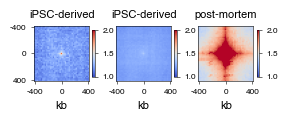

In [73]:
fig=plt.figure(figsize=(3,6))
fig.add_subplot(1,3,1)
plt.imshow(np.nanmean(ipsc_wu,axis=2),cmap='coolwarm',vmin=1,vmax=2)
plt.xticks([0,n,2*n],np.array([-n,0,n])*20)
plt.yticks([0,n,2*n],np.array([-n,0,n])*20)
plt.xlabel('kb')
plt.colorbar(shrink=0.1)
plt.title('iPSC-derived')
fig.add_subplot(1,3,2)
plt.imshow(np.nanmean(ipsc_ciceri,axis=2),cmap='coolwarm',vmin=1,vmax=2)
plt.xticks([0,n,2*n],np.array([-n,0,n])*20)
plt.yticks([])
plt.xlabel('kb')
plt.colorbar(shrink=0.1)
plt.title('iPSC-derived')
fig.add_subplot(1,3,3)
plt.imshow(np.nanmean(pm_dong,axis=2),cmap='coolwarm',vmin=1,vmax=2)
plt.xticks([0,n,2*n],np.array([-n,0,n])*20)
plt.yticks([])
plt.xlabel('kb')
plt.colorbar(shrink=0.1)
plt.title('post-mortem')

#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/long_range_interactions_of_broad_peaks_merged_3plot.pdf')

In [121]:
################################### GWAS ###########################################

In [24]:
#####################################################################################################3

In [105]:
tested_loci='/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/BD_gwas_from_table28_hg38_converted_by_rs_2col.txt'
res=20000
dist=5000000
dist_limit=40000
fdr=0.05

path='/media/anna/Samsung_T5/culture_vs_postmortem/polyc/'

files=['Eres_iPSC_5kb.sampled_exact.mcool',
       'Artrial_D0_iPSC_5K.mcool',
       'Lu2020_iPSC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Rajarajan_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Zaghi2023_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']

#'Eres','Artrial','Lu2020',
contacts_autism={}  
names=['Eres','Artrial','Lu2020','Bal_NPC','Rajarajan_NPC','Zaghi_NPC','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Rahman2023_Fetal','Heffel(2T)','Heffel(3T)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']


for i in range(len(files)):
    coolers=path+files[i]+'::/resolutions/20000'
    print(coolers)
    contacts_autism[names[i]]=contact_hunter.get_contacts(coolers,tested_loci,20000,
    dist,dist_limit,fdr,False,chromosomes='all')

/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Eres_iPSC_5kb.sampled_exact.mcool::/resolutions/20000
The number of CPUs allocated for this task: 10
..1
..2
..4
..3
..4
..1
..5
..5
..2
..3
..1
..2
..2
..4
..3
..5
..1
..2
..2
..6
/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Artrial_D0_iPSC_5K.mcool::/resolutions/20000
The number of CPUs allocated for this task: 10
..1
..2
..3
..4
..4
..1
..2
..5
..5
..1
..3
..2
..4
..2
..3
..5
..1
..2
..2
..6
/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Lu2020_iPSC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool::/resolutions/20000
The number of CPUs allocated for this task: 10
..1
..2
..4
..3
..4
..1
..5
..5
..2
..1
..3
..2
..2
..4
..3
..5
..1
..2
..2
..6
/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Ballerino2022_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool::/resolutions/20000
The number of CPUs allocated for this task: 10
..1
..2
..4
..3
..4
..1
..5
..2
..5
..3
..1
..2
..2
..4
..3
..5
..1
..2
..2
..6
/media/anna/Samsung_T5/culture_

In [108]:
total_cont_au=pd.DataFrame()
for k in contacts_autism.keys():
    df_tmp=contacts_autism[k]
    df_tmp=df_tmp[['chr','bin_to_test','interacting_bin_coord']]
    total_cont_au=pd.concat([total_cont_au,df_tmp],axis=0)

total_cont_au['lab']=total_cont_au.chr+':'+total_cont_au[['bin_to_test','interacting_bin_coord']].min(axis=1).astype(str)+':'+total_cont_au[['bin_to_test','interacting_bin_coord']].max(axis=1).astype(str)

total_cont_au.drop_duplicates('lab',inplace=True)



In [110]:
path='/media/anna/Samsung_T5/culture_vs_postmortem/polyc/'

files=['Eres_iPSC_5kb.sampled_exact.mcool',
       'Artrial_D0_iPSC_5K.mcool',
       'Lu2020_iPSC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Rajarajan_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Zaghi2023_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']

samples_snp_au={} 
names=['Eres','Artrial','Lu_iPSC','Bal_NPC','Rajarajan_NPC','Zaghi_NPC','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Rahman2023_Fetal','Heffel(2T)','Heffel(3T)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']

k=0
cont=total_cont_au[['chr','bin_to_test','interacting_bin_coord']]
cont.columns=['chrom','start1','start2']
cont.start1=(cont.start1/20000).astype(int)
cont.start2=(cont.start2/20000).astype(int)

for f in files:
    dots=np.zeros(len(cont))
    dots[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(cont['chrom']):
        tmp=cont.loc[cont['chrom']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            dots[l]=np.nanmean(m[x-1:x+2,y-1:y+2])
            l+=1
    samples_snp_au[names[k]]=dots
    k+=1

/tmp/ipykernel_15260/2455142108.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cont.start1=(cont.start1/20000).astype(int)
/tmp/ipykernel_15260/2455142108.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cont.start2=(cont.start2/20000).astype(int)


In [111]:
k=0
cont=total_cont_au[['chr','bin_to_test','interacting_bin_coord']].copy()
cont.columns=['chrom','start1','start2']
cont.start1=(cont.start1/20000).astype(int)
cont.start2=(cont.start2/20000).astype(int)


chroms=[]
start1=[]
start2=[]


for ch in np.unique(cont['chrom']):
    tmp=cont.loc[cont['chrom']==ch]
    for i in range(len(tmp)):
        chroms.append(tmp.iloc[i]['chrom'])
        start1.append(tmp.iloc[i]['start1'])
        start2.append(tmp.iloc[i]['start2'])
coords_au=pd.DataFrame({'chrom':chroms,'bin_to_test':start1,'interacting_bin':start2})



snp_samples_df_au=pd.DataFrame()
for k in samples_snp_au.keys():
    snp_samples_df_au[k]=samples_snp_au[k]

snp_samples_df2_au=snp_samples_df_au.dropna()



In [112]:
dz=snp_samples_df2_au.transpose()

from sklearn.decomposition import PCA

dz_m=np.mean(dz,axis=0)
dz_v=np.std(dz,axis=0)

dz=(dz-dz_m)/dz_v

pca = PCA(n_components=5)
X=pca.fit(dz).transform(dz)

pca.explained_variance_ratio_


array([0.21443899, 0.11405216, 0.06872868, 0.05777633, 0.04688128])

In [ ]:
#MDD array([0.22384498, 0.13384338, 0.06549033, 0.06238571, 0.05019062])

In [ ]:
#BD array([0.1986996 , 0.14215147, 0.07706154, 0.06183765, 0.04881303])
#BD new array([0.21443899, 0.11405216, 0.06872868, 0.05777633, 0.04688128])

In [ ]:
# AD array([0.20224461, 0.10046599, 0.08135517, 0.07123423, 0.05199539])

In [171]:
# Autism array([0.20136003, 0.1394014 , 0.06178212, 0.05079674, 0.04833791])#check - 0.19790882, 0.13484175

In [172]:
# SCizoph array([0.23972591, 0.14176016, 0.0798637 , 0.05790065, 0.04478947])

In [113]:

pca_df=pd.DataFrame(X[:,0:2])

pca_df.index=['Eres', 'Artrial', 'Lu', 'Ballarino', 'Rajarajan', 'Zaghi',
       'Ballarino', 'Li', 'Rahman_iPSC', 'Wu', 'Zaghi', 'Rajarajan_iPSCder', 'Our data',
       'Rahman_Fetal', 'Heffel(2T)', 'Heffel(3T)', 'Heffel(infant)',
       'Heffel(adult)', 'Hu', 'Our_data', 'Rahman', 'Tian']

pca_df.columns=['PC1','PC2']

pca_df['group']=['iPSC']*3+['NPC']*3+['iPSC-derived neurons']*7+['Fetal neurons']*3+['Post-mortem neurons']*6

pca_df['sample_simple']=pca_df.index



pca_df.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/PC1_PC2_data_for_BD_new_from_tab28_0.21_0.11_aggregated_check.txt',sep='\t',index=None)


In [ ]:
###################

In [114]:
tested_loci='/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/BD_gwas_from_table28_hg38_converted_by_rs_2col.txt'
res=20000
dist=5000000
dist_limit=40000
fdr=0.05

path='/media/anna/Samsung_T5/culture_vs_postmortem/polyc/'

files=[
 'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']

contacts_autism={}  
names=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']


for i in range(len(files)):
    coolers=path+files[i]+'::/resolutions/20000'
    print(coolers)
    contacts_autism[names[i]]=contact_hunter.get_contacts(coolers,tested_loci,20000,
    dist,dist_limit,fdr,False,chromosomes='all')

/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool::/resolutions/20000
The number of CPUs allocated for this task: 10
..1
..2
..3
..4
..4
..1
..5
..5
..2
..3..1

..2
..2
..4
..3
..1
..5
..2
..2
..6
/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Li2022_iPSC_NeuNplus.sampled_exact.mcool::/resolutions/20000
The number of CPUs allocated for this task: 10
..1
..2
..3
..4
..4
..1
..5
..5
..2
..3
..1
..2
..2
..4
..3
..5
..1
..2
..2
..6
/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool::/resolutions/20000
The number of CPUs allocated for this task: 10
..1
..2
..4
..3
..4
..1
..5
..5
..2
..1
..3
..2
..2
..4
..3
..5
..1
..2
..2
..6
/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Wu2021_iPSC_NeuNplus.sampled_exact.mcool::/resolutions/20000
The number of CPUs allocated for this task: 10
..1
..2
..3
..4
..4
..1
..5
..5
..2
..3
..1
..2
..2
..4
..3
..1
..5
..2
..2
..6
/

In [115]:
total_cont_nc_au=pd.DataFrame()
for k in ['Ballerino', 'Li', 'Rahman_iPSC', 'Wu', 'Zaghi', 'PsychENCODE', 'Lag', 'Heffel(infant)', 'Heffel(adult)', 'Hu', 'Plet', 'Rahman', 'Tian']:
    df_tmp=contacts_autism[k]
    df_tmp=df_tmp[['chr','bin_to_test','interacting_bin_coord']]
    total_cont_nc_au=pd.concat([total_cont_nc_au,df_tmp],axis=0)

total_cont_nc_au['lab']=total_cont_nc_au.chr+':'+total_cont_nc_au[['bin_to_test','interacting_bin_coord']].min(axis=1).astype(str)+':'+total_cont_nc_au[['bin_to_test','interacting_bin_coord']].max(axis=1).astype(str)

total_cont_nc_au.drop_duplicates('lab',inplace=True)

#total_cont_nc_au.sort_values(['chr','bin_to_test','interacting_bin_coord']).to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/contacts_snp_across_2_cell_types_BD_from_tab28.txt',sep='\t',index=None)

In [116]:
path='/media/anna/Samsung_T5/culture_vs_postmortem/polyc/'

files=[
 'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']

samples_snp_nc_au={} 
names=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']

k=0
cont=total_cont_nc_au[['chr','bin_to_test','interacting_bin_coord']]
cont.columns=['chrom','start1','start2']
cont.start1=(cont.start1/20000).astype(int)
cont.start2=(cont.start2/20000).astype(int)

for f in files:
    dots=np.zeros(len(cont))
    dots[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(cont['chrom']):
        tmp=cont.loc[cont['chrom']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            dots[l]=np.nanmean(m[x-1:x+2,y-1:y+2])
            l+=1
    samples_snp_nc_au[names[k]]=dots
    k+=1


    
k=0
cont=total_cont_nc_au[['chr','bin_to_test','interacting_bin_coord']]
cont.columns=['chrom','start1','start2']
cont.start1=(cont.start1/20000).astype(int)
cont.start2=(cont.start2/20000).astype(int)

chroms=[]
start1=[]
start2=[]

for ch in np.unique(cont['chrom']):
    tmp=cont.loc[cont['chrom']==ch]
    for i in range(len(tmp)):
        chroms.append(tmp.iloc[i]['chrom'])
        start1.append(tmp.iloc[i]['start1'])
        start2.append(tmp.iloc[i]['start2'])
coords_nc_au=pd.DataFrame({'chrom':chroms,'bin_to_test':start1,'interacting_bin':start2})



/tmp/ipykernel_15260/410638068.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cont.start1=(cont.start1/20000).astype(int)
/tmp/ipykernel_15260/410638068.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cont.start2=(cont.start2/20000).astype(int)
/tmp/ipykernel_15260/410638068.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

In [117]:
snp_samples_df_nc_au=pd.DataFrame()
for k in samples_snp_nc_au.keys():
    snp_samples_df_nc_au[k]=samples_snp_nc_au[k]



In [118]:
snp_samples_df_nc_au_coord=pd.concat([snp_samples_df_nc_au,coords_nc_au],axis=1)

In [119]:
snp_samples_df_nc_au_coord.dropna(inplace=True)

In [120]:
snp_samples_df_nc_au_coord

,Ballerino,Li,Rahman_iPSC,Wu,Zaghi,PsychENCODE,Lag,Heffel(infant),Heffel(adult),Hu,Plet,Rahman,Tian,chrom,bin_to_test,interacting_bin
0,0.497458,0.465788,0.232851,0.346427,0.000000,0.637012,1.232021,0.000000,0.757345,0.659325,0.484692,0.573813,0.570213,chr1,4806,4562
1,2.121535,1.959657,1.795002,1.722403,1.884696,1.845618,1.724886,1.616068,1.331458,1.358292,1.375594,1.340070,1.392132,chr1,4806,4763
2,2.628733,2.436912,2.230939,2.507994,2.094582,2.189593,2.002881,1.383503,1.358837,1.772989,1.572549,1.873880,1.555628,chr1,4806,4765
3,2.045207,1.802328,1.866450,1.960898,1.782063,1.562967,1.936814,1.527965,1.982388,1.512953,1.635292,1.755748,1.524505,chr1,4806,4767
4,1.426614,1.444263,1.007354,1.292118,1.164431,1.331529,1.328434,1.017717,1.339969,1.110230,0.933292,1.206105,1.029825,chr1,4806,4832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,1.195624,1.187422,1.169863,1.467953,1.141358,1.224962,1.116552,0.811833,1.051638,0.926735,0.998620,1.028735,1.033830,chr9,858,874
4916,0.723916,0.792798,0.574912,0.749982,1.152785,1.018188,1.054521,0.752697,1.186958,0.839653,0.961869,0.635035,1.130779,chr9,858,981
4917,2.168277,1.152918,0.731101,1.630844,0.550665,1.609272,1.573523,0.443269,1.220631,1.778441,0.901298,2.050822,2.190003,chr9,858,1100
4918,1.210916,1.247249,1.208622,1.834217,0.555533,1.274982,1.469092,1.816677,0.467394,1.306019,1.747915,1.047631,2.504842,chr9,858,1106


In [121]:
snp_samples_df_nc_au_coord.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/table_snps_BD_from_tab28_aggregated_with_bins_info.txt',sep='\t',index=None)

In [122]:
snp_samples_df_nc_au2=snp_samples_df_nc_au.dropna()

In [123]:
snp_samples_df_nc_au2

,Ballerino,Li,Rahman_iPSC,Wu,Zaghi,PsychENCODE,Lag,Heffel(infant),Heffel(adult),Hu,Plet,Rahman,Tian
0,0.497458,0.465788,0.232851,0.346427,0.000000,0.637012,1.232021,0.000000,0.757345,0.659325,0.484692,0.573813,0.570213
1,2.121535,1.959657,1.795002,1.722403,1.884696,1.845618,1.724886,1.616068,1.331458,1.358292,1.375594,1.340070,1.392132
2,2.628733,2.436912,2.230939,2.507994,2.094582,2.189593,2.002881,1.383503,1.358837,1.772989,1.572549,1.873880,1.555628
3,2.045207,1.802328,1.866450,1.960898,1.782063,1.562967,1.936814,1.527965,1.982388,1.512953,1.635292,1.755748,1.524505
4,1.426614,1.444263,1.007354,1.292118,1.164431,1.331529,1.328434,1.017717,1.339969,1.110230,0.933292,1.206105,1.029825
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,1.195624,1.187422,1.169863,1.467953,1.141358,1.224962,1.116552,0.811833,1.051638,0.926735,0.998620,1.028735,1.033830
4916,0.723916,0.792798,0.574912,0.749982,1.152785,1.018188,1.054521,0.752697,1.186958,0.839653,0.961869,0.635035,1.130779
4917,2.168277,1.152918,0.731101,1.630844,0.550665,1.609272,1.573523,0.443269,1.220631,1.778441,0.901298,2.050822,2.190003
4918,1.210916,1.247249,1.208622,1.834217,0.555533,1.274982,1.469092,1.816677,0.467394,1.306019,1.747915,1.047631,2.504842


In [124]:
snp_samples_df_nc_au2[['Ballerino', 'Li', 'Wu', 'Zaghi', 'PsychENCODE', 'Lag',
       'Heffel(infant)', 'Heffel(adult)', 'Hu', 'Plet', 'Rahman', 'Tian']].to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/snp_recalling_for_limma_2_cell_types_BD_from_tab28_no_rahman_aggregated.txt',sep='\t')



In [3]:
files=['limma_result_recalling_20K_BD_tab28_2_cell_types.txt',
      'limma_result_recalling_20K_MDD_2_cell_types.txt',
      'limma_result_recalling_20K_ad_2_cell_types.txt',
      'limma_result_recalling_20K_autism_2_cell_types.txt',
      'limma_result_recalling_20K_scz_2_cell_types.txt']

In [8]:
for i in range(len(files)):
    f=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/%s'%files[i],sep='\t')
    print('up_in_neu ',len(f.loc[(f['adj.P.Val']<0.05)&(f.logFC>0)]), files[i].split('_')[4])
    print('up_in_iPSC ',len(f.loc[(f['adj.P.Val']<0.05)&(f.logFC<0)]), files[i].split('_')[4])
    print('total ',len(f), files[i].split('_')[4])

up_in_neu  194 BD
up_in_iPSC  121 BD
total  4838 BD
up_in_neu  360 MDD
up_in_iPSC  331 MDD
total  9098 MDD
up_in_neu  73 ad
up_in_iPSC  18 ad
total  3692 ad
up_in_neu  180 autism
up_in_iPSC  171 autism
total  3894 autism
up_in_neu  1429 scz
up_in_iPSC  903 scz
total  23263 scz


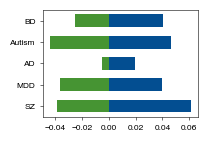

In [125]:
ipsc='#469433'
pm='#034e91'
plt.figure(figsize=(2,1.4))
plt.barh(1,-903/23263,color=ipsc,height=0.6)
plt.barh(1,1429/23263,color=pm,height=0.6)
plt.barh(2,-331/9098,color=ipsc,height=0.6)
plt.barh(2,360/9098,color=pm,height=0.6)
plt.barh(3,-18/3692,color=ipsc,height=0.6)
plt.barh(3,73/3692,color=pm,height=0.6)
plt.barh(4,-171/3894,color=ipsc,height=0.6)
plt.barh(4,180/3894,color=pm,height=0.6)
plt.barh(5,-121/4838,color=ipsc,height=0.6)
plt.barh(5,194/4838,color=pm,height=0.6)

plt.yticks([1,2,3,4,5],['SZ','MDD','AD','Autism','BD'])
#plt.yticks([1,2,3,4,5],[1,2,3,4,5])
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/proportions.pdf')

In [238]:
files=['limma_result_recalling_20K_BD_tab28_2_cell_types.txt',
      'limma_result_recalling_20K_MDD_2_cell_types.txt',
      'limma_result_recalling_20K_ad_2_cell_types.txt',
      'limma_result_recalling_20K_autism_2_cell_types.txt',
      'limma_result_recalling_20K_scz_2_cell_types.txt']

coords=['table_snps_BD_aggregated_with_bins_info.txt',
'table_snps_MDD_aggregated_with_bins_info.txt',
'table_snps_ad_aggregated_with_bins_info.txt',
'table_snps_autism_aggregated_with_bins_info.txt',
'table_snps_scz_aggregated_with_bins_info.txt']

names=['BD','MDD','AD','Autism','SCZ']

genes=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/genes_coordinates_hg38.txt',sep='\t',header=None)
genes_bed=pybedtools.BedTool.from_dataframe(genes[[0,1,2,3]])

df_logFC=pd.DataFrame()

for i in range(len(files)):
    f=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/%s'%files[i],sep='\t')
    f.sort_index(inplace=True)
    coord=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/%s'%coords[i],sep='\t')
    coord['limma_pval_adj']=list(f['adj.P.Val'])
    coord['limma_pval_logFC']=list(f['logFC'])

    info=coord[['chrom', 'bin_to_test', 'interacting_bin', 'limma_pval_adj',
       'limma_pval_logFC']]

    sign=info.loc[info.limma_pval_adj<0.05]
    sign['interacting_bin_end']=sign['interacting_bin']*20000+40000
    sign['interacting_bin_start']=sign['interacting_bin']*20000-20000

    neu_spec_bins_bed=pybedtools.BedTool.from_dataframe(sign.loc[sign.limma_pval_logFC>0][['chrom','interacting_bin_start','interacting_bin_end']])
    cult_spec_bins_bed=pybedtools.BedTool.from_dataframe(sign.loc[sign.limma_pval_logFC<0][['chrom','interacting_bin_start','interacting_bin_end']])

    neu_genes=genes_bed.intersect(neu_spec_bins_bed).to_dataframe()
    cult_genes=genes_bed.intersect(cult_spec_bins_bed).to_dataframe()

    neu_genes[['name']].drop_duplicates().to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/snp_dif_cont_genes/%s_genes_in_snp_neu_spec_contacts_plus_minus_20K.txt'%names[i],sep='\t',index=None)
    cult_genes[['name']].drop_duplicates().to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/snp_dif_cont_genes/%s_genes_in_snp_cult_spec_contacts_plus_minus_20K.txt'%names[i],sep='\t',index=None)
    tmp=info[['limma_pval_logFC']]
    tmp['disease']=names[i]
    df_logFC=pd.concat([df_logFC,tmp],axis=0)


/tmp/ipykernel_11991/2677891473.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sign['interacting_bin_end']=sign['interacting_bin']*20000+40000
/tmp/ipykernel_11991/2677891473.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sign['interacting_bin_start']=sign['interacting_bin']*20000-20000
/tmp/ipykernel_11991/2677891473.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

In [133]:
p='/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/'

In [134]:
files=['BD_gwas_from_table28_hg38_converted_by_rs_2col.txt','MDDM_gwas_hg38_converted_by_rs_2col.txt','ag_gwas_hg38_converted_by_rs_2col.txt',
      'autism_snps_for_cont_hunt_2col.txt','snp_from_pardinas_2col.txt']

In [135]:
bin_numb=[]
for f in files:
    tmp=pd.read_csv(p+f,sep='\t',header=None)
    tmp[1]=(tmp[1]/20000).astype(int)
    print(len(tmp))
    tmp.drop_duplicates(inplace=True)
    bin_numb.append(len(tmp))

59
177
1236
360
5782


In [136]:
bin_numb

[58, 177, 99, 64, 872]

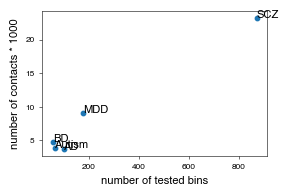

In [137]:
plt.figure(figsize=(3,2))
X=np.array([55, 177, 64, 872, 99])
Y=np.array([4838,9098,3894,23269,3692])/1000
plt.scatter(X,Y,s=10)
l=['BD','MDD','Autism','SCZ','AD']

for i in range(len(X)):
    plt.text(X[i],Y[i],l[i],fontsize=8) 
          
plt.xlabel('number of tested bins')
plt.ylabel('number of contacts * 1000')
plt.tight_layout()

In [138]:
df=pd.DataFrame({'snps':[58, 177, 64, 872, 99],'contacts':[4838,9098,3894,23269,3692]})
df.index=['BD','MDD','Autism','SCZ','AD']

In [139]:
df=df.loc[['SCZ','MDD','AD','Autism','BD' ]]

In [140]:
df

,snps,contacts
SCZ,872,23269
MDD,177,9098
AD,99,3692
Autism,64,3894
BD,58,4838


In [278]:
df.snps/df.contacts*1000

SCZ       37.474752
MDD       19.454825
AD        26.814735
Autism    16.435542
BD        11.988425
dtype: float64

SCZ
MDD
AD
Autism
BD


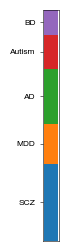

In [143]:
fig=plt.figure(figsize=(0.2,3))
bottom = 0
yt=[]
k=0

for c in df.snps/df.contacts*1000:
    print(df.index[k])
    p = plt.bar([1], c, width=0.1,label=df.index[k], bottom=bottom)
    yt.append(bottom+c/2)
    bottom += c
    k+=1
plt.yticks(yt,df.index)
plt.xticks([])
plt.ylim(0,bottom)
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/contacts_per_bins_in_diseases_BD_tab28.pdf')

In [ ]:
p='/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/'

files=['BD_gwas_hg38_converted_by_rs_2col.txt','MDDM_gwas_hg38_converted_by_rs_2col.txt','ag_gwas_hg38_converted_by_rs_2col.txt',
      'autism_snps_for_cont_hunt_2col.txt','snp_from_pardinas_2col.txt']

bin_numb=[]
for f in files:
    tmp=pd.read_csv(p+f,sep='\t',header=None)
    snp_bed=pybedtools.BedTool.from_dataframe(tmp[[0,1,1]])


In [126]:
snp_ad=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/ag_gwas_hg38_converted_by_rs_2col.txt',sep='\t',header=None)
snp_autism=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/autism_snps_for_cont_hunt_2col.txt',sep='\t',header=None)
snp_bd=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/BD_gwas_from_table28_hg38_converted_by_rs_2col.txt',sep='\t',header=None)
snp_scz=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/snp_from_pardinas_2col.txt',sep='\t',header=None)
snp_mdd=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/MDDM_gwas_hg38_converted_by_rs_2col.txt',sep='\t',header=None)

In [127]:
snp_ad['lab']=snp_ad[0]+':'+snp_ad[1].astype(str)
snp_ad['lab_bin']=snp_ad[0]+':'+(snp_ad[1]/20000).astype(int).astype(str)

snp_autism['lab']=snp_autism[0]+':'+snp_autism[1].astype(str)
snp_autism['lab_bin']=snp_autism[0]+':'+(snp_autism[1]/20000).astype(int).astype(str)

snp_bd['lab']=snp_bd[0]+':'+snp_bd[1].astype(str)
snp_bd['lab_bin']=snp_bd[0]+':'+(snp_bd[1]/20000).astype(int).astype(str)

snp_scz['lab']=snp_scz[0]+':'+snp_scz[1].astype(str)
snp_scz['lab_bin']=snp_scz[0]+':'+(snp_scz[1]/20000).astype(int).astype(str)

snp_mdd['lab']=snp_mdd[0]+':'+snp_mdd[1].astype(str)
snp_mdd['lab_bin']=snp_mdd[0]+':'+(snp_mdd[1]/20000).astype(int).astype(str)


In [164]:
set(snp_bd.lab)&set(snp_scz.lab)&set(snp_mdd.lab)

{'chr15:90883330'}

In [165]:
set(snp_scz.lab)&set(snp_mdd.lab)

{'chr15:90883330', 'chr2:57760458', 'chr3:16809700'}

In [166]:
set(snp_bd.lab)&set(snp_scz.lab)

{'chr14:99252882', 'chr15:90883330', 'chr3:36814539'}

In [169]:
set(snp_bd.lab)&set(snp_mdd.lab)

{'chr15:90883330',
 'chr16:7612809',
 'chr17:40062551',
 'chr19:51278201',
 'chr6:151942225'}

In [168]:
set(snp_bd.lab_bin)&set(snp_scz.lab_bin)&set(snp_mdd.lab_bin)

{'chr15:4544'}

<Figure size 300x300 with 0 Axes>

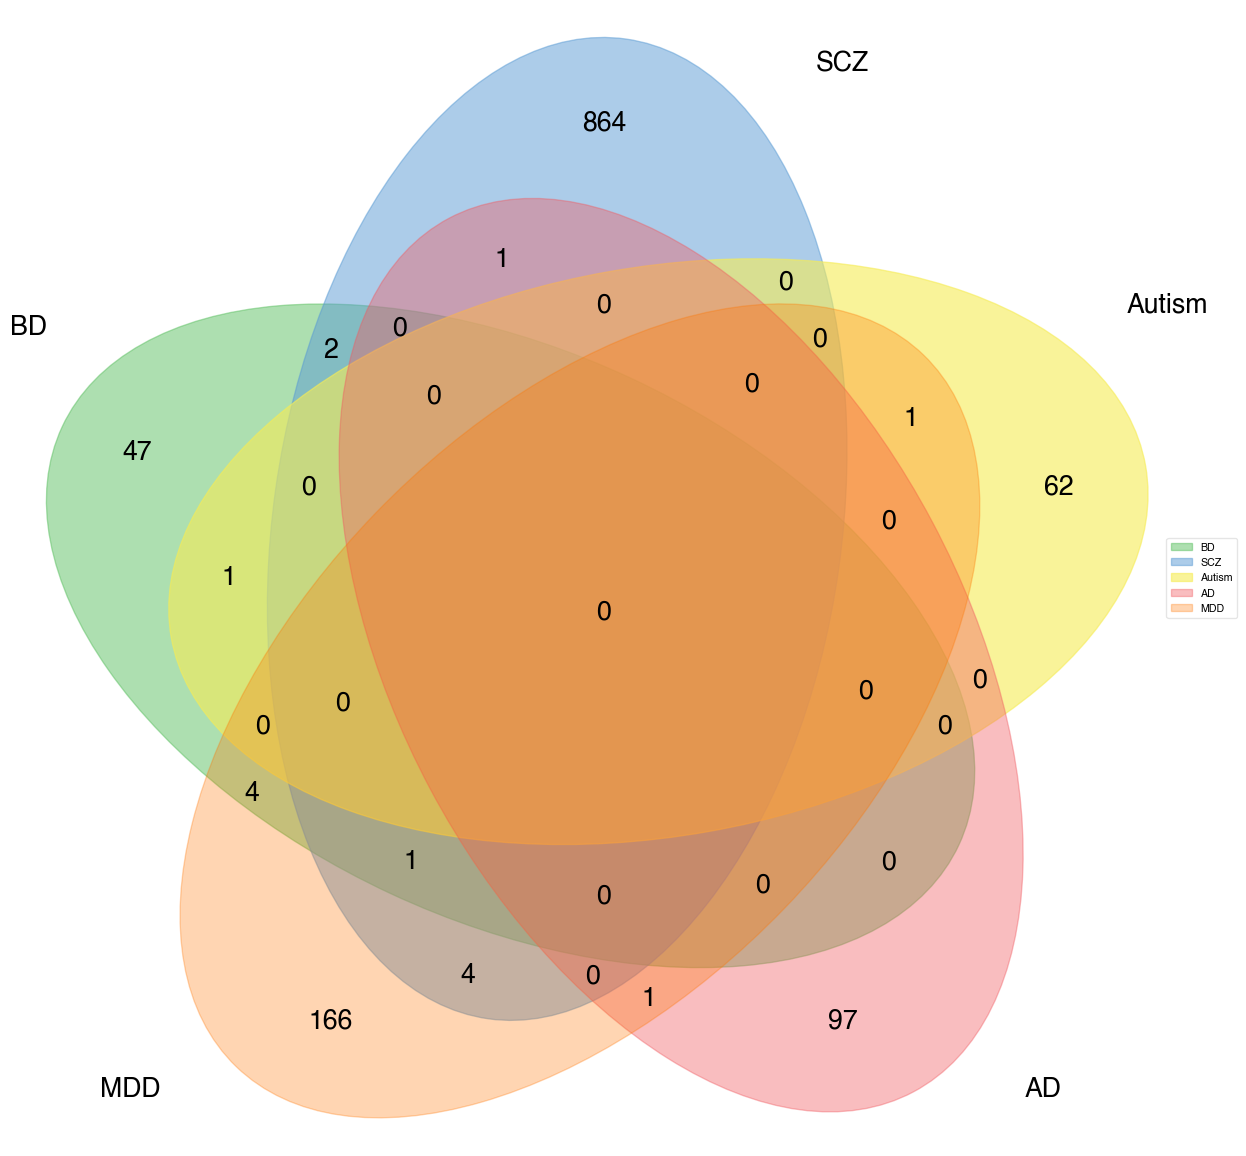

In [177]:
import sys
sys.path.insert(1, '/home/anna/Downloads/pyvenn/')
import venn
plt.figure(figsize=(3,3))
labels = venn.get_labels([set(snp_bd.lab_bin),set(snp_scz.lab_bin),set(snp_autism.lab_bin),set(snp_ad.lab_bin),set(snp_mdd.lab_bin)], fill=['number'])
venn.venn5(labels, names=['BD','SCZ','Autism','AD','MDD'],fontsize=20,alpha=0.5)#,colors=['#034e9150','#46943350']
plt.tight_layout()
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/vien_for_disease_snp.pdf')


In [128]:
import upsetplot
from upsetplot import from_contents
from upsetplot import  plot

<Figure size 200x300 with 0 Axes>

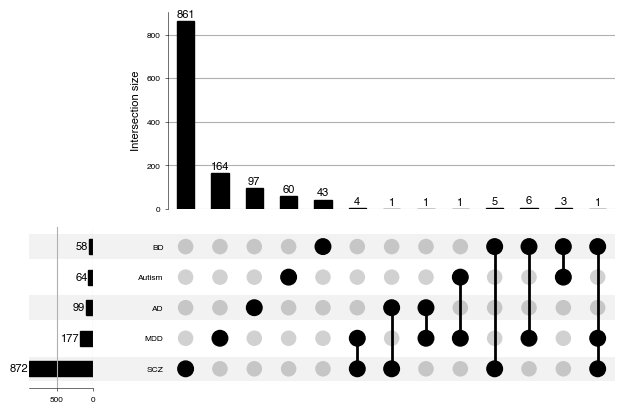

In [129]:
plt.figure(figsize=(2,3))
contents={'BD':set(snp_bd.lab_bin),'SCZ':set(snp_scz.lab_bin),'Autism':set(snp_autism.lab_bin),'AD':set(snp_ad.lab_bin),'MDD':set(snp_mdd.lab_bin)}
disorders=from_contents(contents)
plot(disorders,show_counts="{:,}")
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/upsetplot_diseases_snp_overlaps_new_BD_tab28.pdf')

In [22]:
###################### FIREs maps  ####################

In [82]:
cult_super_fires=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/cult_spec_super_fires_with_hef_inf.bed',sep='\t',header=None)

In [88]:
neu_super_fires=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/neu_spec_super_fires_with_hef_inf.bed',sep='\t',header=None)

In [89]:
files=['Eres_iPSC_5kb.sampled_exact.mcool',
       'Artrial_D0_iPSC_5K.mcool',
       'Lu2020_iPSC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Rajarajan_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Zaghi2023_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']


names=['Eres','Artrial','Lu','Ballerino(NPC)','Rajarajan(NPC)','Zaghi(NPC)','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Heffel(2T)','Heffel(3T)','Rahman(fetal)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=0
samples_neu={}
fires=neu_super_fires.copy()
fires[1]=(fires[1]/10000).astype(int)
fires[2]=(fires[2]/10000).astype(int)
d=10
for f in files:
    scores=np.zeros((21,21,len(fires)))
    scores[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/10000'%f)
    l=0
    for ch in np.unique(fires[0]):
        tmp=fires.loc[fires[0]==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x1=tmp.iloc[i][1]
            x2=tmp.iloc[i][2]
            th=np.nanmean(m[x1:x2,x1-10:x2+10],axis=0)
            th1=th[0:d]
            th2=th[-d:]
            
            tv=np.nanmean(m[x1-10:x2+10,x1:x2],axis=1)
            tv1=tv[0:d]
            tv2=tv[-d:]
            
            t1=m[x1-10:x1,x1-10:x1]
            t2=m[x1-10:x1,x2:x2+10]
            t3=m[x2:x2+10,x1-10:x1]
            t4=m[x2:x2+10,x2:x2+10]
            scores[0:d,0:d,l]=t1
            scores[0:d,-d:,l]=t2
            scores[-d:,0:d,l]=t3
            scores[-d:,-d:,l]=t4
            scores[d,0:d,l]=th1
            scores[d,-d:,l]=th2            
            scores[0:d,d,l]=tv1
            scores[-d:,d,l]=tv2
            scores[d,d]=np.mean(np.nanmean(m[x1:x2,x1:x2]))
            l+=1
            
    samples_neu[names[k]]=scores
    k+=1


0.08294406211526575 iPSC
0.07363923188466714 NPC
0.09155466867609659 iPSC-derived
0.1738406252678893 Fetal
0.3144233805378078 Post-mortem


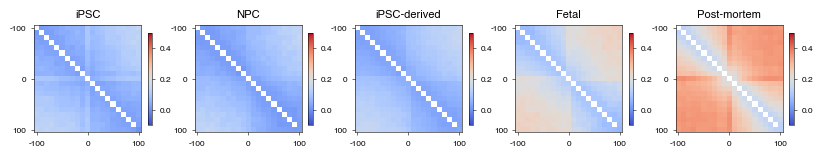

In [122]:
f1=['Eres','Artrial','Lu']
f2=['Ballerino(NPC)','Rajarajan(NPC)','Zaghi(NPC)']
f3=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag']
f4=['Heffel(2T)','Heffel(3T)','Rahman(fetal)']
f5=['Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=1

names=['iPSC','NPC','iPSC-derived','Fetal','Post-mortem']
n=0
x1=[]
for f in f3:
    x1.append(np.nanmean(samples_neu[f],axis=2))
iPSCder=np.nanmean(x1,axis=0)  

fig=plt.figure(figsize=(10,2))
for clas in [f1,f2,f3,f4,f5]:
    fig.add_subplot(1,5,k)
    x1=[]
    for f in clas:
        x1.append(np.nanmean(samples_neu[f],axis=2))
    x2=np.nanmean(x1,axis=0)
    print(np.mean(np.log(x2)[10,:]),names[n])
    for i in range(len(x2)-1):
        x2[i,i]=np.nan
    plt.imshow(np.log(x2),cmap='coolwarm',vmin=-0.1,vmax=0.5)
    plt.colorbar(shrink=0.6)
    plt.xticks([0,10,20],[-100,0,100])
    plt.yticks([0,10,20],[-100,0,100])
    plt.title(names[n])
    n+=1
    k+=1
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/fires_neu_spec_heatmaps.pdf')

0.03470108154205894 iPSC
0.09253936005220714 NPC
0.06632802124619659 iPSC-derived
0.03183205122000894 Fetal
-0.049189958206982014 Post-mortem


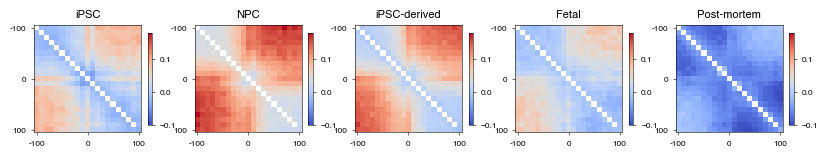

In [129]:
f1=['Eres','Artrial','Lu']
f2=['Ballerino(NPC)','Rajarajan(NPC)','Zaghi(NPC)']
f3=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag']
f4=['Heffel(2T)','Heffel(3T)','Rahman(fetal)']
f5=['Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=1

names=['iPSC','NPC','iPSC-derived','Fetal','Post-mortem']
n=0
x1=[]
for f in f3:
    x1.append(np.nanmean(samples_v2[f],axis=2))
iPSCder=np.nanmean(x1,axis=0)  

fig=plt.figure(figsize=(10,2))
for clas in [f1,f2,f3,f4,f5]:
    fig.add_subplot(1,5,k)
    x1=[]
    for f in clas:
        x1.append(np.nanmean(samples_v2[f],axis=2))
    x2=np.nanmean(x1,axis=0)
    print(np.mean(np.log(x2)[10,:]),names[n])
    for i in range(len(x2)-1):
        x2[i,i]=np.nan
    plt.imshow(np.log(x2),cmap='coolwarm',vmin=-0.1,vmax=0.18)
    plt.colorbar(shrink=0.6)
    plt.xticks([0,10,20],[-100,0,100])
    plt.yticks([0,10,20],[-100,0,100])
    plt.title(names[n])
    n+=1
    k+=1
#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/fires_cult_spec_heatmaps.pdf')